# Set environment

In [3]:
### Basic
import numpy  as np
import scipy  as sc
import pandas as pd
import glob, os, re
import pickle, sys

### keras
from keras            import Sequential, models, layers
from keras.utils      import to_categorical
from keras.optimizers import SGD, Adam

### import flowImg
py_path = "/local_data/notebooks/clintko/GitRepo/Proj_Flow2Image"
sys.path.insert(0, py_path)
from flowImg import *

### sklearn
from sklearn.metrics import roc_curve, auc, accuracy_score

### plot
import matplotlib.pyplot as plt
plt.style.use("seaborn-whitegrid")

### global const
SEED    = 123
DAT_DIR = "/data/clintko/flow_EQAPOL_normal/pipe01"

/local_data/env-py3/lib/python3.6/site-packages/h5py/__init__.py:36: FutureWarning: Conversion of the second argument of issubdtype from `float` to `np.floating` is deprecated. In future, it will be treated as `np.float64 == np.dtype(float).type`.
  from ._conv import register_converters as _register_converters
Using TensorFlow backend.


In [4]:
import tensorflow as tf
from keras import backend as k
### suppress warning
### ref: https://stackoverflow.com/questions/48608776/how-to-suppress-tensorflow-warning-displayed-in-result
tf.logging.set_verbosity(tf.logging.ERROR)

### restrict the memory usage of tensorflow
config = tf.ConfigProto()
config.gpu_options.allow_growth = True
k.tensorflow_backend.set_session(tf.Session(config=config))

### ref: https://machinelearningmastery.com/reproducible-results-neural-networks-keras/
from numpy.random import seed
#seed(SEED)
from tensorflow import set_random_seed
#set_random_seed(SEED)

# Load data

In [3]:
!ls /data/clintko/flow_EQAPOL_normal/pipe01

model_vgg16_lr5e6_bs10_noBNorm.h5	      wrap03_subs_1e4_N10.P
model_vgg16_lr5e6_bs10_noBNorm_history.P      wrap03_subs_1e4_N50.P
model_vgg16_lr5e6_bs10_noBNorm.yaml	      wrap04_tsne_1e4_N10.P
model_vgg16_lre5_bs10_noBNorm.h5	      wrap04_tsne_1e4_N50.P
model_vgg16_noBNorm_lr5e6_bs10_SEB.h5	      wrap05_img_1e4_N50_var01.P
model_vgg16_noBNorm_lr5e6_bs10_SEB_history.P  wrap05_img_1e4_N50_var10.P
model_vgg16_noBNorm_lr5e6_bs10_SEB.yaml       wrap05_img_1e4_var01.P
wrap01_data.P				      wrap05_img_1e4_var02.P
wrap02_scaled_k0.P			      wrap05_img_1e4_var05.P
wrap03_subs_1e4_N100.P			      wrap05_img_1e4_var10.P


In [2]:
###
fname = "wrap05_img_1e4_N50_var01.P"
#fname = "wrap05_img_1e4_var01.P"
fpath = os.path.join(DAT_DIR, fname)
file  = open(fpath, "rb")
wrap_tsne_v01 = pickle.load(file)
file.close()

NameError: name 'os' is not defined

# Split to train and test data

In [1]:
dat_img = wrap_tsne_v01
dat_img_train, dat_img_test = train_test_split_datawrapper(
    dat_img, 8, 50)
print(dat_img_train)
print(dat_img_test)

NameError: name 'wrap_tsne_v01' is not defined

# get image

In [6]:
def set_label_onevsrest(label, target):
    label = label.copy()
    label[label != target] = 0
    label[label == target] = 1
    return label

In [7]:
target = 2 # SEB

In [8]:
img_train = dat_img_train.img
img_train = img_train.reshape((-1, 128, 128, 14))

y_train = dat_img_train.label.copy()
y_train = set_label_onevsrest(y_train, target)
print(y_train)
y_train = to_categorical(y_train)

print(img_train.shape)
print(y_train.shape)

[0 0 0 ... 1 1 1]
(1200, 128, 128, 14)
(1200, 2)


In [9]:
img_test = dat_img_test.img
img_test = img_test.reshape((-1, 128, 128, 14))

y_test = dat_img_test.label.copy()
y_test = set_label_onevsrest(y_test, target)
print(y_test)
y_test = to_categorical(y_test)

print(img_test.shape)
print(y_test.shape)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1]
(450, 128, 128, 14)
(450, 2)


# Build model

In [10]:
input_shape = (128, 128, 14)
n_class     = 2

### VGG16

In [11]:
### set model
np.random.seed(SEED)
set_random_seed(SEED)
model = Sequential()

model.add(layers.Conv2D(64, (3, 3), input_shape=input_shape, padding='same', activation='relu'))
model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))
model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same'))
model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same'))
model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same'))
model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))
model.add(layers.Conv2D(512, (3, 3), activation='relu', padding='same'))
model.add(layers.Conv2D(512, (3, 3), activation='relu', padding='same'))
model.add(layers.Conv2D(512, (3, 3), activation='relu', padding='same'))
model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))
model.add(layers.Conv2D(512, (3, 3), activation='relu', padding='same'))
model.add(layers.Conv2D(512, (3, 3), activation='relu', padding='same'))
model.add(layers.Conv2D(512, (3, 3), activation='relu', padding='same'))
model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))
model.add(layers.Flatten())
model.add(layers.Dense(4096,    activation='relu'))
model.add(layers.Dense(4096,    activation='relu'))
model.add(layers.Dense(n_class, activation='softmax'))

### compile the model
adam = Adam(lr=0.000005)
model.compile(
    optimizer=adam,
    loss='categorical_crossentropy',
    metrics=['accuracy'])

### name the model
model_vgg16 = model

In [12]:
#model_vgg16.summary()
model_vgg16.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_1 (Conv2D)            (None, 128, 128, 64)      8128      
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 128, 128, 64)      36928     
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 64, 64, 64)        0         
_________________________________________________________________
conv2d_3 (Conv2D)            (None, 64, 64, 128)       73856     
_________________________________________________________________
conv2d_4 (Conv2D)            (None, 64, 64, 128)       147584    
_________________________________________________________________
max_pooling2d_2 (MaxPooling2 (None, 32, 32, 128)       0         
_________________________________________________________________
conv2d_5 (Conv2D)            (None, 32, 32, 256)       295168    
__________

In [13]:
%%time
### Train the model
history = model_vgg16.fit(
    img_train, 
    y_train,
    epochs = 20,
    batch_size = 10,
    validation_data=(img_test, y_test))

Train on 1200 samples, validate on 450 samples
Epoch 1/20
1200/1200 [==============================] - 15s 12ms/step - loss: 0.6281 - acc: 0.6775 - val_loss: 0.5556 - val_acc: 0.8378
Epoch 2/20
1200/1200 [==============================] - 11s 9ms/step - loss: 0.1865 - acc: 0.9308 - val_loss: 0.0111 - val_acc: 0.9978
Epoch 3/20
1200/1200 [==============================] - 11s 9ms/step - loss: 0.0260 - acc: 0.9933 - val_loss: 0.0027 - val_acc: 1.0000
Epoch 4/20
1200/1200 [==============================] - 11s 9ms/step - loss: 0.0032 - acc: 0.9992 - val_loss: 0.0019 - val_acc: 1.0000
Epoch 5/20
1200/1200 [==============================] - 11s 9ms/step - loss: 8.2471e-04 - acc: 1.0000 - val_loss: 8.4628e-04 - val_acc: 1.0000
Epoch 6/20
1200/1200 [==============================] - 11s 9ms/step - loss: 2.7580e-04 - acc: 1.0000 - val_loss: 0.0014 - val_acc: 1.0000
Epoch 7/20
1200/1200 [==============================] - 11s 9ms/step - loss: 1.7879e-04 - acc: 1.0000 - val_loss: 6.7733e-04 - val

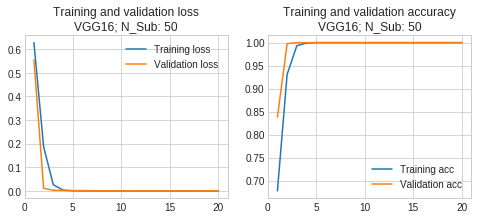

In [14]:
title   = "\nVGG16; N_Sub: 50"

### extract the training / validation loss from fitting history
acc      = history.history['acc']
val_acc  = history.history['val_acc']
loss     = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

### visualize the training / validation loss
fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(8, 3))
ax = axes[0]
ax.plot(epochs, loss,     '-', label='Training loss')
ax.plot(epochs, val_loss, '-',  label='Validation loss')
ax.set_title('Training and validation loss' + title)
ax.legend()

ax = axes[1]
ax.plot(epochs, acc,      '-', label='Training acc')
ax.plot(epochs, val_acc,  '-',  label='Validation acc')
ax.set_title('Training and validation accuracy' + title)
ax.legend()

plt.show()

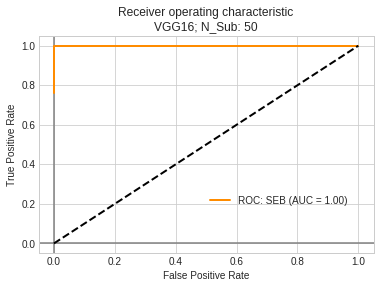

In [15]:
y_prob = model_vgg16.predict_proba(img_test)

### calculate fpr and tpr
i = 1
fpr, tpr, roc_auc = dict(), dict(), dict()
fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_prob[:, i])
roc_auc[i] = auc(fpr[i], tpr[i])

### Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_test.ravel(), y_prob.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

#######################################################
### set plot
plt.figure()
lw = 2

### since there is only two classes, below are the same
plt.plot(fpr[1], tpr[1], color='darkorange', lw=lw, label='ROC: SEB (AUC = %0.2f)' % roc_auc[1])

### visualize ROC curve
plt.plot([0, 1], [0, 1], color='black', lw=lw, linestyle='--')
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.vlines(0, -0.05, 1.05, color = "Gray")
plt.hlines(0, -0.05, 1.05, color = "Gray")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic' + title)
plt.legend(loc=(0.5, 0.2)) #plt.legend(loc="lower right")

plt.show()

# store the model   
https://machinelearningmastery.com/save-load-keras-deep-learning-models/

In [16]:
model = model_vgg16

In [17]:
### history
fname = os.path.join(DAT_DIR, "model_vgg16_noBNorm_lr5e6_bs50_SEB_history.P")
with open(fname, "wb") as file:
    pickle.dump(history.history, file)

# serialize model to YAML
model_yaml = model.to_yaml()
fname = os.path.join(DAT_DIR, "model_vgg16_noBNorm_lr5e6_bs50_SEB.yaml")
with open(fname, "w") as file:
    file.write(model_yaml)
    
# serialize weights to HDF5
fname = os.path.join(DAT_DIR, "model_vgg16_noBNorm_lr5e6_bs50_SEB.h5")
model.save_weights(fname)
print("Saved model to disk")

Saved model to disk


In [18]:
!ls /data/clintko/flow_EQAPOL_normal/pipe01

model_vgg16_lr5e6_bs10_noBNorm.h5	      wrap03_subs_1e4_N100.P
model_vgg16_lr5e6_bs10_noBNorm_history.P      wrap03_subs_1e4_N10.P
model_vgg16_lr5e6_bs10_noBNorm.yaml	      wrap03_subs_1e4_N50.P
model_vgg16_lre5_bs10_noBNorm.h5	      wrap04_tsne_1e4_N10.P
model_vgg16_noBNorm_lr5e6_bs10_SEB.h5	      wrap04_tsne_1e4_N50.P
model_vgg16_noBNorm_lr5e6_bs10_SEB_history.P  wrap05_img_1e4_N50_var01.P
model_vgg16_noBNorm_lr5e6_bs10_SEB.yaml       wrap05_img_1e4_N50_var10.P
model_vgg16_noBNorm_lr5e6_bs50_SEB.h5	      wrap05_img_1e4_var01.P
model_vgg16_noBNorm_lr5e6_bs50_SEB_history.P  wrap05_img_1e4_var02.P
model_vgg16_noBNorm_lr5e6_bs50_SEB.yaml       wrap05_img_1e4_var05.P
wrap01_data.P				      wrap05_img_1e4_var10.P
wrap02_scaled_k0.P
